# Kickstarter — Linguistic Patterns & Campaign Success

**Objective:** estimate the association between bigrams in campaign description text and campaign success, controlling for structural variables, with separate analysis per category.

## Structure
1. Setup & data loading
2. Feature engineering
3. Helper functions
4. Intra-category model — bigram


## Methodological note — model

Logistic regression is an **interpretive** tool, not a predictive one. The model estimates:

$$P(\text{success}) = \sigma(\beta_0 + \beta_1 x_1 + \cdots + \beta_k x_k)$$

where $\sigma$ is the sigmoid function. The coefficients $\beta_j$ act on the **log-odds** (the log of the ratio between probability of success and probability of failure):

$$\log\frac{P(\text{success})}{P(\text{failure})} = \beta_0 + \beta_1 x_1 + \cdots + \beta_k x_k$$

Therefore: **a positive coefficient on a bigram means that its presence is associated with an increase in the log-odds of success**, holding all other controls constant. This is not causal inference: it is a conditional association.


## Methodological note — AUC-ROC as a sanity check

The **AUC-ROC** (Area Under the Receiver Operating Characteristic Curve) measures the model's ability to separate the two groups (success vs failure).

- **AUC = 0.5**: the model does not discriminate better than chance (equivalent to a coin flip)
- **AUC = 1.0**: perfect separation
- **AUC > 0.65–0.70**: the model captures real signal

In this notebook the AUC is not used to evaluate the model's *predictive power*, but as a **sanity check**: if it were close to 0.5, the extracted coefficients would be unstable and meaningless. A value substantially above 0.5 guarantees that the regression has captured a real signal, and the bigram coefficients are interpretable.

The estimate is computed using **5-fold stratified cross-validation** to avoid over-optimism.


## Methodological note — coefficient robustness

Bigrams are filtered by `doc_freq >= MIN_DF`. Coefficients on very rare terms are unstable even if large in magnitude: the filter reduces this risk.

## 1. Setup & data loading

In [1]:
import ast
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.sparse import hstack

warnings.filterwarnings('ignore')

# ── Global parameters ──────────────────────────────────────────────────────────
MIN_DF_BIGRAM  = 20      # minimum document frequency threshold — bigram
BASELINE_CAT   = 'Film & Video'
CV_FOLDS       = 5
TOP_N          = 10      # bigrams shown in charts

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

In [3]:
df = pd.read_csv('Kickstarter_processed (2).csv')
df['description_processed'] = df['description_processed'].apply(ast.literal_eval)

print(f'Shape: {df.shape}')
print(f'\nCategories:\n{df["category"].value_counts()}')
print(f'\nStatus (1=success, 0=failure):\n{df["status"].value_counts()}')
df.head(3)

Shape: (7354, 16)

Categories:
category
Film & Video    2011
Technology      1489
Games           1422
Music           1218
Publishing      1214
Name: count, dtype: int64

Status (1=success, 0=failure):
status
1    4510
0    2844
Name: count, dtype: int64


,Unnamed: 0,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency,category,video,reached,status,duration,description_processed,pos_tagged
0,0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD,Film & Video,1,148.172917,1,30,"[entertainment, today, push, unholy, agenda, c...","[('entertainment', 'NN'), ('today', 'NN'), ('p..."
1,1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD,Film & Video,1,106.208130,1,41,"[million, american, college, student, study, a...","[('million', 'CD'), ('american', 'JJ'), ('coll..."
2,2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD,Film & Video,1,5.775000,0,45,"[cartoon, network, type, letter, instead, lett...","[('cartoon', 'NN'), ('network', 'NN'), ('type'..."


## 2. Feature engineering

In [4]:
df['goal_log']    = np.log(df['goal'])
df['text_length'] = df['description_processed'].apply(len)
df['text_joined'] = df['description_processed'].apply(lambda x: ' '.join(x))

CONTROLS   = ['goal_log', 'duration', 'text_length', 'video']
CATEGORIES = df['category'].unique().tolist()

print('Numeric controls:', CONTROLS)
print('Categories:', CATEGORIES)
df[CONTROLS + ['status']].describe().round(3)

Numeric controls: ['goal_log', 'duration', 'text_length', 'video']
Categories: ['Film & Video', 'Games', 'Music', 'Publishing', 'Technology']


,goal_log,duration,text_length,video,status
count,7354.000,7354.000,7354.000,7354.000,7354.000
mean,9.680,34.443,291.292,0.877,0.613
std,0.805,11.260,245.452,0.328,0.487
min,8.517,3.000,15.000,0.000,0.000
25%,9.148,30.000,120.000,1.000,0.000
50%,9.473,30.000,220.000,1.000,1.000
75%,10.127,37.000,386.000,1.000,1.000
max,13.816,91.000,1965.000,1.000,1.000


## 3. Helper functions

In [5]:
def make_model():
    """L2-regularised logistic regression with balanced class weights."""
    return LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        max_iter=500,
        class_weight='balanced'
    )


def evaluate_auc(X, y):
    """
    AUC-ROC in 5-fold stratified CV.
    Sanity check: verifies that the model discriminates between success and
    failure better than chance (AUC >> 0.5). Not a predictive evaluation.
    """
    cv     = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    scores = cross_val_score(make_model(), X, y, cv=cv, scoring='roc_auc')
    return pd.DataFrame({
        'AUC-ROC mean': [round(scores.mean(), 3)],
        'AUC-ROC std':  [round(scores.std(),  3)]
    })


def extract_coefs(model, feature_names, X_text, min_doc_freq, col_name='bigram'):
    """Extract token coefficients with doc_freq filter."""
    coef     = model.coef_[0][:len(feature_names)]
    doc_freq = np.asarray((X_text > 0).sum(axis=0)).flatten()
    info = pd.DataFrame({
        col_name:   feature_names,
        'coef':     coef.round(4),
        'doc_freq': doc_freq
    })
    return info[info['doc_freq'] >= min_doc_freq].copy().reset_index(drop=True)


def show_top(info, col_name, n=TOP_N):
    """Print top n tokens associated with success and failure."""
    cols = [col_name, 'coef', 'doc_freq']
    print(f'\n--- TOP {n} associated with SUCCESS ---')
    display(info.sort_values('coef', ascending=False).head(n)[cols].reset_index(drop=True))
    print(f'\n--- TOP {n} associated with FAILURE ---')
    display(info.sort_values('coef').head(n)[cols].reset_index(drop=True))


def plot_coefs(info, col_name, cat_name, n=TOP_N):
    """
    Horizontal bar chart of the top/bottom n bigrams by coefficient.
    Coefficients are on the log-odds scale: positive = associated with success,
    negative = associated with failure.
    """
    top_success = info.sort_values('coef', ascending=False).head(n)
    top_failure = info.sort_values('coef').head(n)
    combined    = pd.concat([top_success, top_failure]).drop_duplicates(subset=col_name)
    combined    = combined.sort_values('coef')

    colors = ['#d62728' if c < 0 else '#2ca02c' for c in combined['coef']]

    fig, ax = plt.subplots(figsize=(9, max(5, len(combined) * 0.38)))
    bars = ax.barh(combined[col_name], combined['coef'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient (log-odds)', fontsize=11)
    ax.set_title(f'{cat_name} — Bigrams most associated with success (green) and failure (red)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # value annotations
    for bar, val in zip(bars, combined['coef']):
        offset = 0.005 * (combined['coef'].max() - combined['coef'].min())
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + (offset if val >= 0 else -offset),
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha=ha, fontsize=8.5)

    plt.tight_layout()
    plt.show()


def run_intracat_bigram(df, cat, min_df=MIN_DF_BIGRAM):
    """Fit bigram logistic regression on a category subset + AUC-ROC + coefficient extraction."""
    df_cat = df[df['category'] == cat].copy().reset_index(drop=True)
    y_cat  = df_cat['status'].values

    vec    = CountVectorizer(ngram_range=(2, 2), min_df=min_df)
    X_text = vec.fit_transform(df_cat['text_joined'])
    feat   = vec.get_feature_names_out()

    scaler = StandardScaler()
    X_num  = sp.csr_matrix(scaler.fit_transform(df_cat[CONTROLS]))
    X      = hstack([X_text, X_num])

    model  = make_model()
    model.fit(X, y_cat)

    auc_df = evaluate_auc(X, y_cat)
    info   = extract_coefs(model, feat, X_text, min_doc_freq=min_df, col_name='bigram')

    return info, auc_df

## 4. Intra-category model — bigram

**Specification per category:** `P(success) ~ bigram BoW + goal_log + duration + text_length + video`

No category dummies (the model already runs on a homogeneous subset).

For each category the following are reported:
- **AUC-ROC** (5-fold stratified CV): sanity check on the model's discriminative quality
- **Top bigrams associated with success**: positive log-odds coefficients
- **Top bigrams associated with failure**: negative log-odds coefficients
- **Chart**: horizontal bars for immediate reading of coefficients

**How to read the coefficients:** a coefficient of +0.30 on a bigram means that its presence is associated with an increase of 0.30 units in the log-odds of success, holding goal, duration, text length, and video presence constant. On the probability scale the effect is non-linear: the closer the baseline probability is to 0 or 1, the less the log-odds increment translates into a probability increment.


  Film & Video — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.731,0.018


→ AUC = 0.731 ± 0.018: good discriminative ability — coefficients are reliable

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,premier sundance,2.1391,36
1,across america,1.5593,21
2,costume designer,1.4279,45
3,critically acclaim,1.3936,41
4,million view,1.3208,48
5,credit imdb,1.2760,27
6,york los,1.2252,27
7,comedy central,1.2159,33
8,archival footage,1.2127,41
9,murder mystery,1.1610,20



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,diverse group,-1.3791,20
1,television program,-1.2244,20
2,upon completion,-1.0984,20
3,classic horror,-1.0604,23
4,visual storytelling,-1.0151,43
5,push boundary,-0.9847,31
6,prop costume,-0.9273,36
7,horror genre,-0.8572,38
8,native american,-0.8554,31
9,prop wardrobe,-0.8434,25


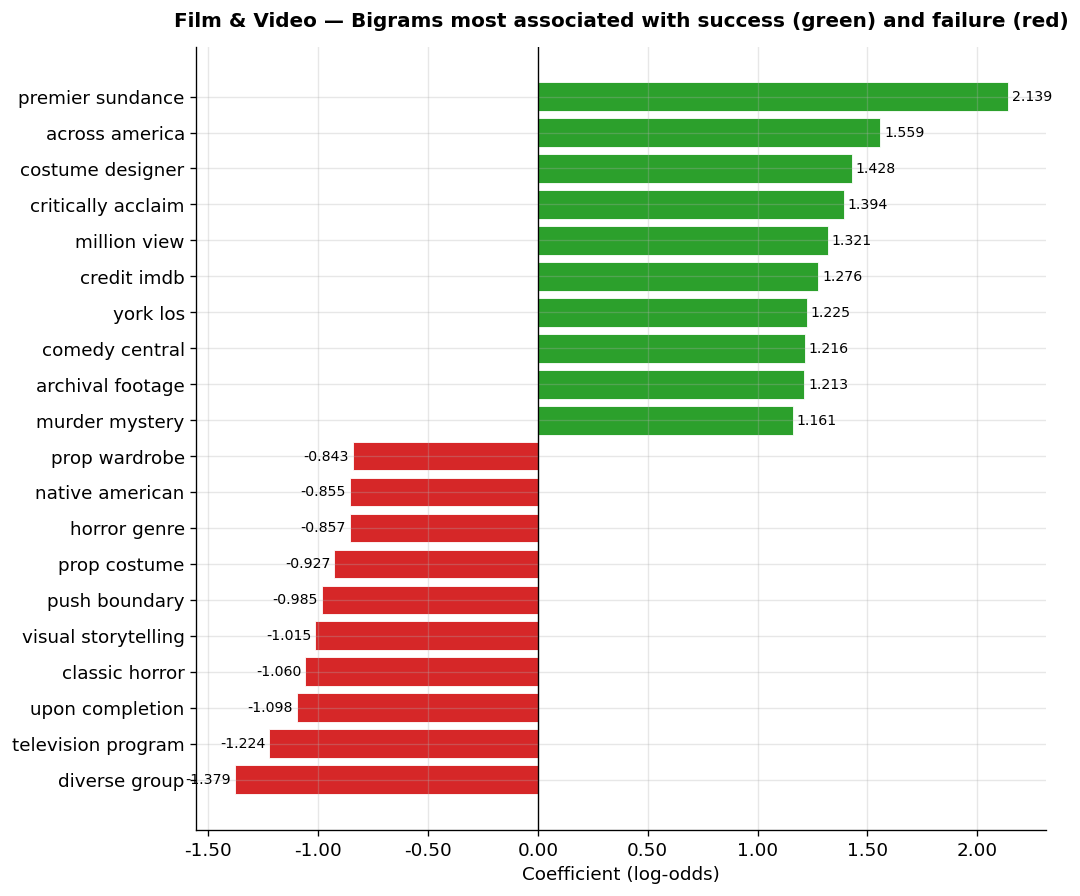


  Games — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.802,0.027


→ AUC = 0.802 ± 0.027: good discriminative ability — coefficients are reliable

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,sixsided dice,1.9118,26
1,steam key,1.5478,28
2,choice shape,1.5306,29
3,backerkit manager,1.4127,33
4,wishlist steam,1.3656,24
5,vat tax,1.3619,27
6,applicable tax,1.3436,24
7,sticker sheet,1.3318,27
8,fulfillment estimate,1.3263,20
9,low price,1.3214,24



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,tabletop roleplaying,-1.3250,29
1,anywhere else,-1.2331,27
2,sneak peek,-0.9977,20
3,anything else,-0.9092,24
4,android io,-0.8730,21
5,south america,-0.8277,20
6,deep dive,-0.8103,22
7,countless hour,-0.7643,34
8,manage resource,-0.7372,25
9,black white,-0.7265,40


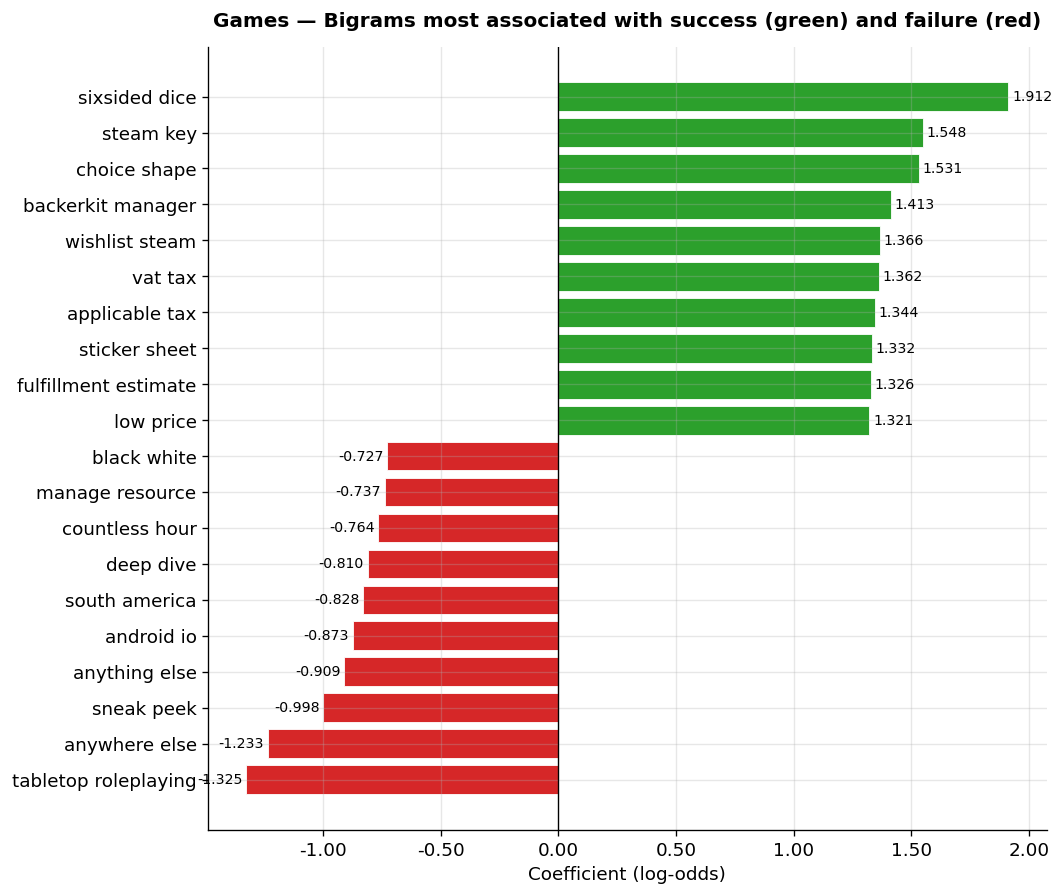


  Music — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.714,0.033


→ AUC = 0.714 ± 0.033: good discriminative ability — coefficients are reliable

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,graphic designer,1.9562,25
1,radio station,1.8294,31
2,string quartet,1.6394,20
3,hire publicist,1.5782,20
4,radio promotion,1.1804,27
5,someone else,0.9470,20
6,bass drum,0.7552,24
7,pass away,0.5093,22
8,united state,0.4019,37
9,across country,0.3693,46



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,drum bass,-0.8314,21
1,facebook twitter,-0.7418,35
2,anyone else,-0.5381,26
3,countless hour,-0.4723,24
4,singer songwriter,-0.4044,30
5,marketing promotion,-0.3334,26
6,thus far,-0.2586,24
7,grammy winner,-0.1941,23
8,north america,-0.1812,23
9,hip hop,-0.1446,34


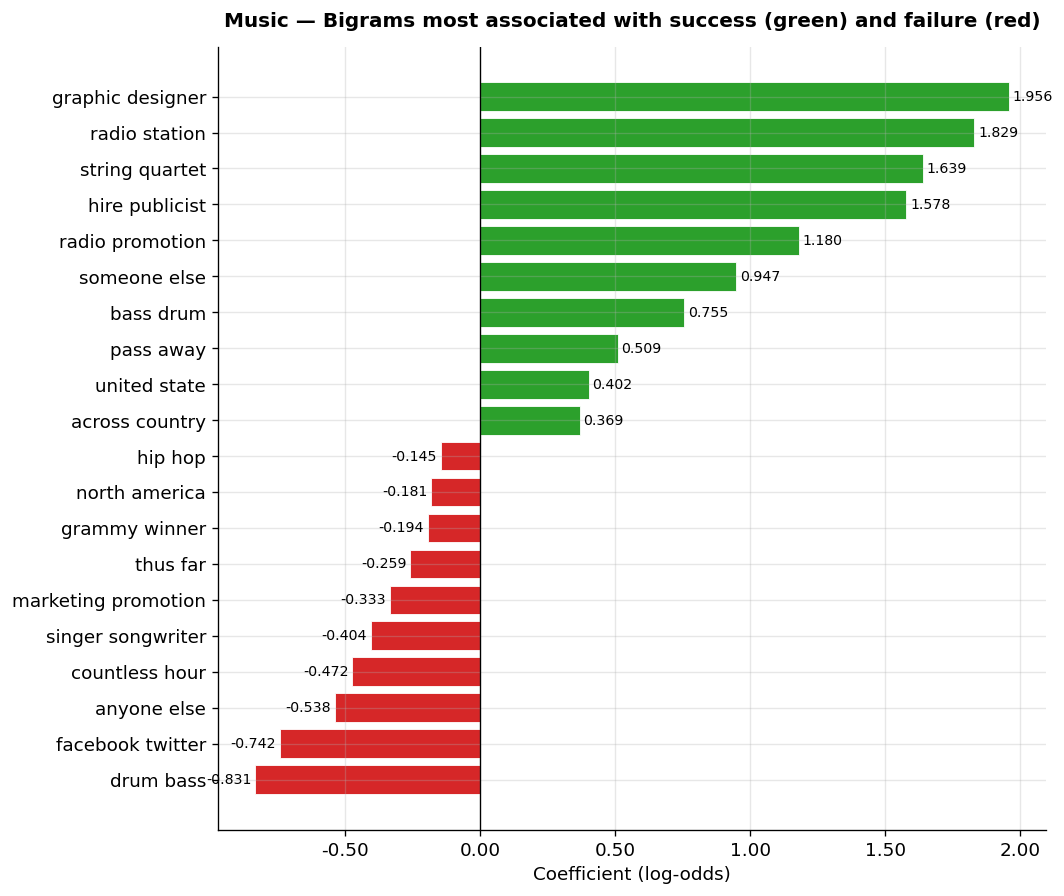


  Publishing — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.67,0.016


→ AUC = 0.670 ± 0.016: moderate discriminative ability — interpret with caution

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,nonprofit organization,1.4655,20
1,sale tax,1.2748,22
2,coffee table,1.0655,30
3,import tax,0.9486,20
4,portland oregon,0.8288,31
5,instagram facebook,0.8255,24
6,subject matter,0.7668,24
7,ten thousand,0.6955,20
8,strange horizon,0.6911,22
9,dust jacket,0.6389,47



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,bridge gap,-0.7931,21
1,state university,-0.6140,28
2,youtube channel,-0.5276,30
3,across globe,-0.4688,20
4,magazine magazine,-0.3779,34
5,radio station,-0.3560,27
6,anyone else,-0.3340,22
7,paperback ebook,-0.2971,25
8,audio drama,-0.2634,27
9,capable replay,-0.2627,54


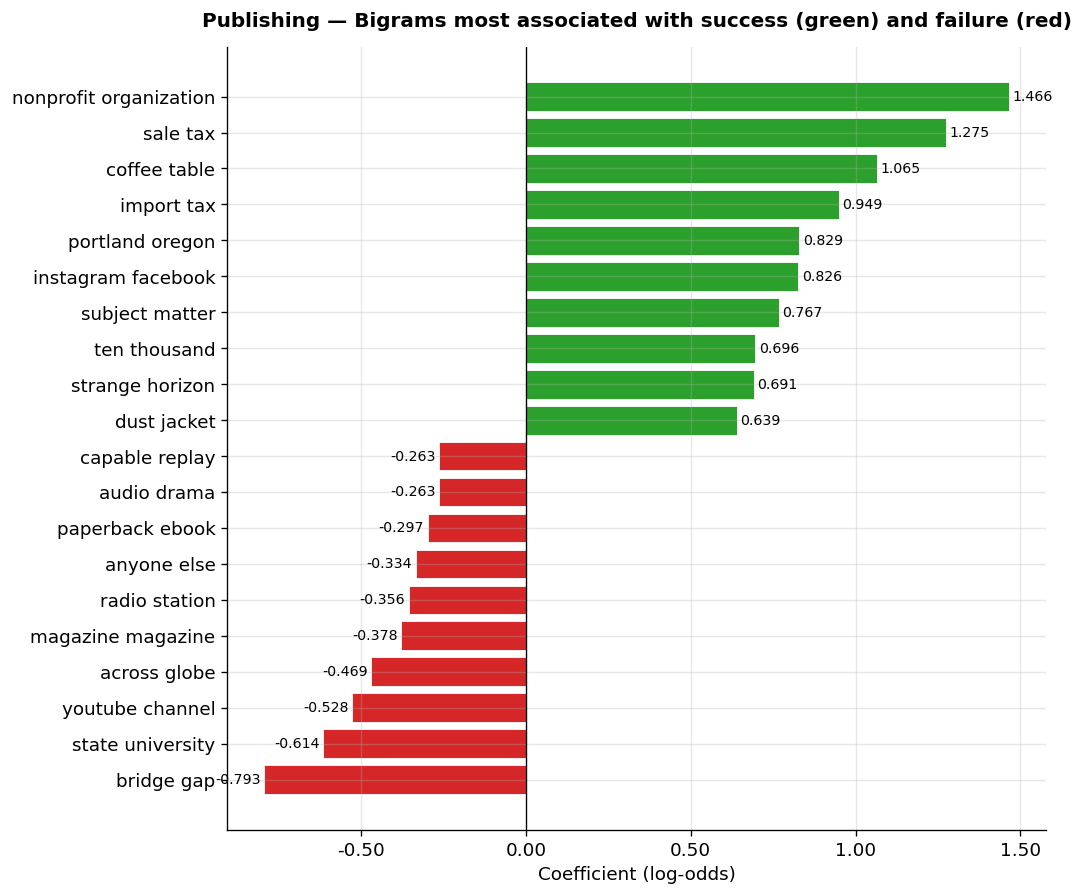


  Technology — bigram

--- AUC-ROC (5-fold stratified CV) ---


,AUC-ROC mean,AUC-ROC std
0,0.753,0.019


→ AUC = 0.753 ± 0.019: good discriminative ability — coefficients are reliable

--- TOP 10 associated with SUCCESS ---


,bigram,coef,doc_freq
0,fully compatible,1.8306,21
1,fully manage,1.7214,22
2,send survey,1.4484,20
3,promote jellop,1.3136,79
4,across country,1.2665,20
5,press kit,1.0983,25
6,field view,1.0249,23
7,android phone,0.9532,27
8,current state,0.9222,20
9,via bluetooth,0.9166,47



--- TOP 10 associated with FAILURE ---


,bigram,coef,doc_freq
0,price point,-1.3066,30
1,cell phone,-0.9218,34
2,front view,-0.8871,20
3,hour continuous,-0.8795,20
4,usb cable,-0.7758,55
5,smart phone,-0.7719,47
6,solder iron,-0.6108,22
7,input output,-0.5910,49
8,answer question,-0.5565,30
9,bluetooth connection,-0.5527,31


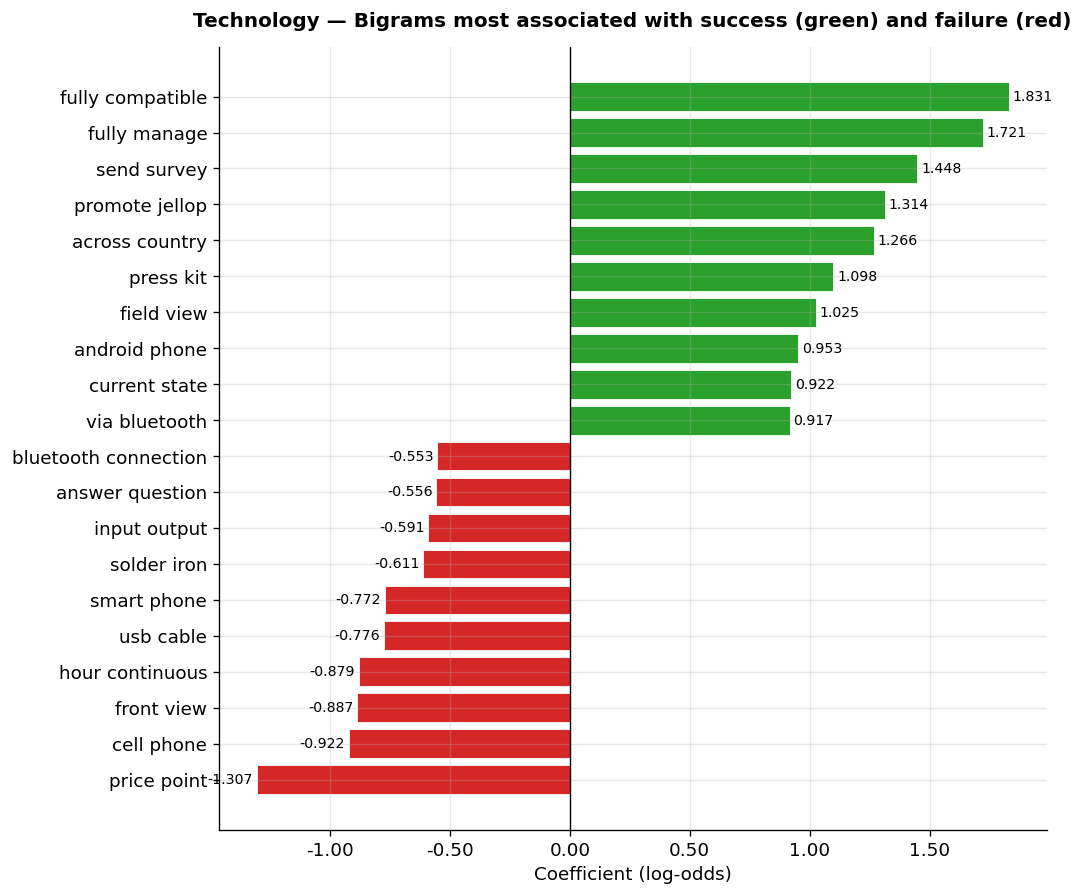

In [6]:
for cat in CATEGORIES:
    print(f'\n{"="*50}')
    print(f'  {cat} — bigram')
    print(f'{"="*50}')

    info, auc_df = run_intracat_bigram(df, cat)

    # ── AUC ──────────────────────────────────────────────────────────────────
    print('\n--- AUC-ROC (5-fold stratified CV) ---')
    auc_mean = auc_df['AUC-ROC mean'].values[0]
    auc_std  = auc_df['AUC-ROC std'].values[0]
    display(auc_df)
    if auc_mean >= 0.70:
        label = 'good discriminative ability — coefficients are reliable'
    elif auc_mean >= 0.60:
        label = 'moderate discriminative ability — interpret with caution'
    else:
        label = 'weak discriminative ability — coefficients should be taken with caution'
    print(f'→ AUC = {auc_mean:.3f} ± {auc_std:.3f}: {label}')

    # ── Coefficient tables ───────────────────────────────────────────────────
    show_top(info, col_name='bigram')

    # ── Chart ─────────────────────────────────────────────────────────────────
    plot_coefs(info, col_name='bigram', cat_name=cat)

## 5. Reading the results — interpretation guide

## AUC-ROC: what it tells us

| Range | Meaning |
|---|---|
| < 0.55 | The model captures no real signal. Coefficients should be ignored. |
| 0.55–0.65 | Weak but present signal. Interpret with great caution. |
| 0.65–0.75 | Moderate signal. Higher-magnitude coefficients are informative. |
| > 0.75 | Strong signal. Coefficients are robust. |

The fact that the model uses only the description text plus a few structural controls (goal, duration, etc.) and still achieves a stable AUC > 0.5 across categories indicates that **the language of descriptions is not irrelevant to success**: there are systematic lexical patterns associated with successful campaigns.


## Logistic regression coefficients: what they mean

The model estimates:

$$\log\frac{P(\text{success})}{1 - P(\text{success})} = \beta_0 + \sum_j \beta_j \cdot \mathbb{1}[\text{bigram}_j \in \text{text}] + \gamma^\top \mathbf{z}$$

where $\mathbf{z}$ are the numeric controls (goal, duration, length, video).

A coefficient $\beta_j > 0$ means:
> *Holding goal, duration, text length and video presence constant, campaigns that use bigram $j$ have a log-odds of success higher by $\beta_j$ compared to those that do not.*

The effect on probability depends on the baseline. For example, with a baseline probability of 0.40 and a coefficient of +0.50:
- Baseline log-odds: $\log(0.40/0.60) = -0.405$
- Log-odds with bigram: $-0.405 + 0.50 = +0.095$
- Updated probability: $\sigma(0.095) \approx 0.524$
- Absolute increase: ~12 percentage points


## Typical patterns to look for

- **Specificity bigrams**: bigrams that describe the product in concrete and specific terms tend to have positive coefficients. Successful campaigns know *what* they are offering.
- **Vagueness bigrams**: generic or rhetorical phrases (e.g. "a better world", "great opportunity") tend to have negative coefficients. The signal is that backers reward concreteness.
- **Category bigrams**: highly technical or niche terms for the category often have positive coefficients — they signal credibility and expertise of the creator.


## Final caveats

1. The analysis is **observational**: we cannot rule out that successful campaigns use certain bigrams *because* their creators are more experienced, and that expertise manifests in other ways not captured by the model.
2. The **L2 regulariser** shrinks coefficients toward zero: absolute magnitude is comparable across bigrams within the same category, but is not directly interpretable as an effect size in the frequentist sense.
3. The **`doc_freq >= 20` filter** excludes very rare bigrams which, despite potentially large coefficients, are statistically unstable.

## Conclusions

**1. Linguistic features carry real signal across all categories.** The bigram-based logistic regression achieves AUC-ROC between 0.67 and 0.80 in every category, all well above the random baseline of 0.5. This confirms that the language used in campaign descriptions is genuinely associated with success, even after controlling for goal size, duration, text length, and video presence.

**2. Games is the most linguistically predictable category (AUC = 0.80).** The model discriminates most cleanly here, suggesting that the vocabulary of successful vs. failing game campaigns is particularly distinct. This likely reflects a more homogeneous, experienced backer community with sharper expectations.

**3. Publishing is the least predictable (AUC = 0.67).** The weaker signal may reflect higher heterogeneity within the category — books, magazines, comics, and poetry attract very different audiences — making it harder to isolate a shared linguistic fingerprint of success.

**4. Proven track record dominates Film & Video.** The top success bigrams — *premier sundance*, *critically acclaim*, *credit imdb*, *million view*, *comedy central* — all signal prior professional validation. Successful film campaigns talk about what they have already achieved, not what they intend to do.

**5. Operational specificity marks successful Games campaigns.** Bigrams like *backerkit manager*, *fulfillment estimate*, *vat tax*, *applicable tax*, and *steam key* indicate that winning campaigns address logistics concretely. Backers reward creators who show they have thought through delivery, not just game design.

**6. Music success correlates with professional infrastructure.** *Hire publicist*, *radio station*, *radio promotion*, and *graphic designer* suggest that successful music campaigns communicate a professional operation around the music — not just artistic content. Having a team and a distribution plan matters.

**7. Rhetorical vagueness is consistently penalised.** Across categories, bigrams like *push boundary*, *visual storytelling*, *bridge gap*, *countless hour*, *deep dive*, and *anyone/anything/anywhere else* are associated with failure. These are generic, aspirational phrases that add no informational value for the backer.

**8. Category self-labelling tends to hurt.** Bigrams such as *horror genre*, *tabletop roleplaying*, *singer songwriter*, and *drum bass* — which essentially name the genre rather than describe the specific project — appear on the failure side. Successful campaigns seem to show rather than label.

**9. Technology campaigns are penalised for hardware-generic language.** *Cell phone*, *usb cable*, *smart phone*, *bluetooth connection*, *input output* are all negative signals. These are commodity terms that fail to differentiate the product. Successful tech campaigns use more specific functional language (*fully compatible*, *fully manage*, *field view*, *via bluetooth* in a concrete context).

**10. The results are observational and cannot be used prescriptively.** The associations identified are conditional on the training data and reflect what successful creators happened to write, not necessarily what caused their success. A failing campaign that adds *premier sundance* to its description will not become successful. The patterns are diagnostic, not causal — they describe a type of communicative competence that tends to co-occur with success, not a formula to replicate it.